<a href="https://colab.research.google.com/github/NGENZIthacien/Individual-work/blob/main/Final_exam_data_mining_19_July_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving telecom_customer_data.csv to telecom_customer_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('telecom_customer_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (403, 18)


,CustomerID,Region,AgeGroup,Gender,SubscriptionPlan,TenureMonths,MonthlyChargeFRW,DataUsedGB,CallMinutes,SMSCount,ComplaintCount,SupportCalls,NetworkQualityScore,PaymentDelayDays,Channel,SatisfactionScore,Churned,TotalRevenue6M
0,MTN00001,Kigali,55+,Male,Basic,37,3655,9.6,680,2,7,8,4.9,8.0,Mobile App,5.3,0,15359
1,MTN00002,Kigali,18-24,Male,Premium,62,17932,37.2,370,124,4,3,3.5,3.0,USSD,NaN,1,90541
2,MTN00003,Kigali,35-44,Male,Basic,3,3594,12.9,768,139,5,9,2.0,10.0,USSD,6.4,1,18199
3,MTN00004,Eastern Province,45-54,Male,Basic,6,3311,30.5,556,112,5,0,4.2,4.0,USSD,6.5,1,18494
4,MTN00005,Northern Province,45-54,Female,Business,15,34769,42.9,351,102,5,0,1.7,13.0,Web,5.5,0,148883


In [ ]:
print("MISSING VALUES PER COLUMN")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDUPLICATE ROWS")
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated CustomerID:", df['CustomerID'].duplicated().sum())

print("\nINCONSISTENT TEXT (categorical columns)")
for col in ['Region', 'AgeGroup', 'Gender', 'SubscriptionPlan', 'Channel']:
    print(f"{col}: {sorted(df[col].unique())}")

print("\nNUMERIC RANGES (look for impossible min/max)")
print(df.describe().T[['min', 'max', 'mean']])

MISSING VALUES PER COLUMN
DataUsedGB              8
NetworkQualityScore    12
PaymentDelayDays        6
SatisfactionScore       9
dtype: int64

DUPLICATE ROWS
Fully duplicated rows: 3
Duplicated CustomerID: 3

INCONSISTENT TEXT (categorical columns)
Region: ['Eastern Province', 'Kigali', 'Northern Province', 'Southern Province', 'Western Province', 'kigali']
AgeGroup: ['18-24', '25-34', '35-44', '45-54', '55+']
Gender: ['Female', 'Male', 'male']
SubscriptionPlan: ['BASIC', 'Basic', 'Business', 'Premium', 'Standard']
Channel: ['Agent', 'Mobile App', 'USSD', 'Walk-in', 'Web', 'mobile app']

NUMERIC RANGES (look for impossible min/max)
                         min       max          mean
TenureMonths             1.0      71.0     36.263027
MonthlyChargeFRW      3206.0  850000.0  13686.779156
DataUsedGB               0.3     999.0     27.761772
CallMinutes             16.0    9999.0    419.342432
SMSCount                 0.0     199.0    101.503722
ComplaintCount           0.0       7.0   

In [ ]:
print("Extreme MonthlyChargeFRW values:")
print(df.sort_values('MonthlyChargeFRW', ascending=False)[['CustomerID', 'MonthlyChargeFRW']].head(3))

print("\nExtreme DataUsedGB values:")
print(df.sort_values('DataUsedGB', ascending=False)[['CustomerID', 'DataUsedGB']].head(3))

print("\nExtreme CallMinutes values:")
print(df.sort_values('CallMinutes', ascending=False)[['CustomerID', 'CallMinutes']].head(3))

print("\nExtreme SatisfactionScore values (scale should be 1-10):")
print(df.sort_values('SatisfactionScore', ascending=False)[['CustomerID', 'SatisfactionScore']].head(3))

Extreme MonthlyChargeFRW values:
    CustomerID  MonthlyChargeFRW
33    MTN00034            850000
203   MTN00204             35287
233   MTN00234             35279

Extreme DataUsedGB values:
    CustomerID  DataUsedGB
7     MTN00008       999.0
34    MTN00035        49.9
372   MTN00373        49.8

Extreme CallMinutes values:
    CustomerID  CallMinutes
89    MTN00090         9999
391   MTN00392          799
261   MTN00262          798

Extreme SatisfactionScore values (scale should be 1-10):
    CustomerID  SatisfactionScore
145   MTN00146               25.0
362   MTN00363               10.0
118   MTN00119               10.0


In [ ]:
before = len(df)
df = df.drop_duplicates(subset='CustomerID', keep='first')  # keep first occurrence, drop exact repeats
after = len(df)
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")

Removed 3 duplicate rows. New shape: (400, 18)


In [ ]:
# Standardise capitalisation so "kigali" and "Kigali" count as the same category
df['Region'] = df['Region'].str.strip().str.title()
df['Gender'] = df['Gender'].str.strip().str.title()
df['SubscriptionPlan'] = df['SubscriptionPlan'].str.strip().str.title()
df['Channel'] = df['Channel'].str.strip().str.title()

print("Region:", sorted(df['Region'].unique()))
print("Gender:", sorted(df['Gender'].unique()))
print("SubscriptionPlan:", sorted(df['SubscriptionPlan'].unique()))
print("Channel:", sorted(df['Channel'].unique()))

Region: ['Eastern Province', 'Kigali', 'Northern Province', 'Southern Province', 'Western Province']
Gender: ['Female', 'Male']
SubscriptionPlan: ['Basic', 'Business', 'Premium', 'Standard']
Channel: ['Agent', 'Mobile App', 'Ussd', 'Walk-In', 'Web']


In [ ]:
# MonthlyChargeFRW: 850,000 is ~50x the 75th percentile -> data-entry error
df.loc[df['MonthlyChargeFRW'] > 100000, 'MonthlyChargeFRW'] = np.nan

# DataUsedGB: 999.0 is a sentinel/placeholder value, not real usage
df.loc[df['DataUsedGB'] > 500, 'DataUsedGB'] = np.nan

# CallMinutes: 9999 is the same kind of sentinel value
df.loc[df['CallMinutes'] > 2000, 'CallMinutes'] = np.nan

# SatisfactionScore: scale is documented as 1-10, so 25 is impossible
df.loc[df['SatisfactionScore'] > 10, 'SatisfactionScore'] = np.nan

print("Outliers converted to NaN — will be imputed in the next step.")

Outliers converted to NaN — will be imputed in the next step.


In [ ]:
# Fill with MEDIAN (not mean) because the mean is sensitive to skew/outliers
numeric_cols_to_impute = ['DataUsedGB', 'NetworkQualityScore', 'PaymentDelayDays',
                           'SatisfactionScore', 'MonthlyChargeFRW', 'CallMinutes']

for col in numeric_cols_to_impute:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled {col} missing values with median = {median_val:.2f}")

Filled DataUsedGB missing values with median = 25.20
Filled NetworkQualityScore missing values with median = 3.10
Filled PaymentDelayDays missing values with median = 14.00
Filled SatisfactionScore missing values with median = 6.40
Filled MonthlyChargeFRW missing values with median = 8444.00
Filled CallMinutes missing values with median = 397.00


In [ ]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print()
print(df[['MonthlyChargeFRW', 'DataUsedGB', 'CallMinutes', 'SatisfactionScore']].describe().T[['min', 'max']])

Total missing values: 0
Total duplicate rows: 0

                      min      max
MonthlyChargeFRW   3206.0  35287.0
DataUsedGB            0.3     49.9
CallMinutes          16.0    799.0
SatisfactionScore     1.9     10.0


In [ ]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print()
print(df[['MonthlyChargeFRW', 'DataUsedGB', 'CallMinutes', 'SatisfactionScore']].describe().T[['min', 'max']])

Total missing values: 0
Total duplicate rows: 0

                      min      max
MonthlyChargeFRW   3206.0  35287.0
DataUsedGB            0.3     49.9
CallMinutes          16.0    799.0
SatisfactionScore     1.9     10.0


In [ ]:
df.to_csv('telecom_clean.csv', index=False)
print("Saved telecom_clean.csv with shape", df.shape)

from google.colab import files
files.download('telecom_clean.csv')

Saved telecom_clean.csv with shape (400, 18)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

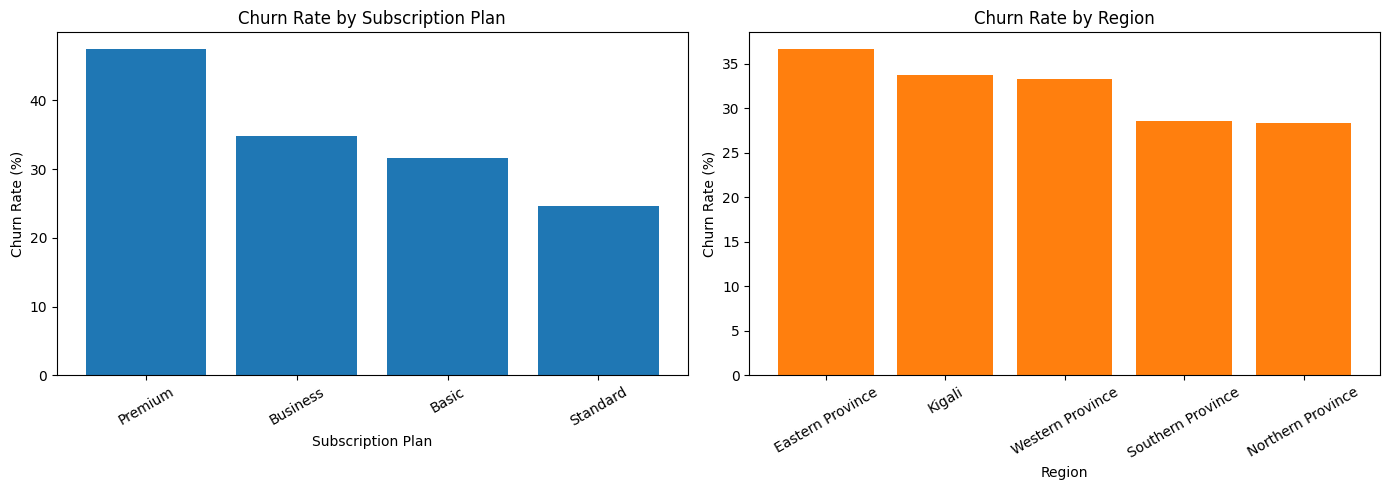

SubscriptionPlan
Premium     47.500000
Business    34.782609
Basic       31.578947
Standard    24.590164
Name: Churned, dtype: float64
Region
Eastern Province     36.708861
Kigali               33.742331
Western Province     33.333333
Southern Province    28.571429
Northern Province    28.333333
Name: Churned, dtype: float64


In [ ]:
churn_by_plan = df.groupby('SubscriptionPlan')['Churned'].mean().sort_values(ascending=False) * 100
churn_by_region = df.groupby('Region')['Churned'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(churn_by_plan.index, churn_by_plan.values, color='#1f77b4')
axes[0].set_title('Churn Rate by Subscription Plan')
axes[0].set_xlabel('Subscription Plan')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(churn_by_region.index, churn_by_region.values, color='#ff7f0e')
axes[1].set_title('Churn Rate by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(churn_by_plan)
print(churn_by_region)

                     Retained (0)  Churned (1)
ComplaintCount           3.138060     4.446970
SatisfactionScore        6.622388     5.878030
TenureMonths            37.496269    33.886364
NetworkQualityScore      3.161940     2.879545


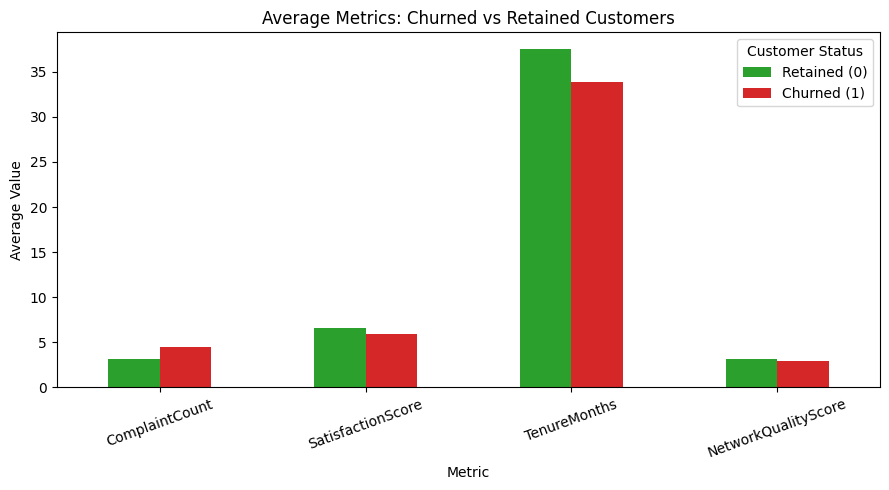

In [ ]:
compare_cols = ['ComplaintCount', 'SatisfactionScore', 'TenureMonths', 'NetworkQualityScore']
comparison = df.groupby('Churned')[compare_cols].mean().T
comparison.columns = ['Retained (0)', 'Churned (1)']
print(comparison)

comparison.plot(kind='bar', figsize=(9, 5), color=['#2ca02c', '#d62728'])
plt.title('Average Metrics: Churned vs Retained Customers')
plt.xlabel('Metric')
plt.ylabel('Average Value')
plt.xticks(rotation=20)
plt.legend(title='Customer Status')
plt.tight_layout()
plt.show()

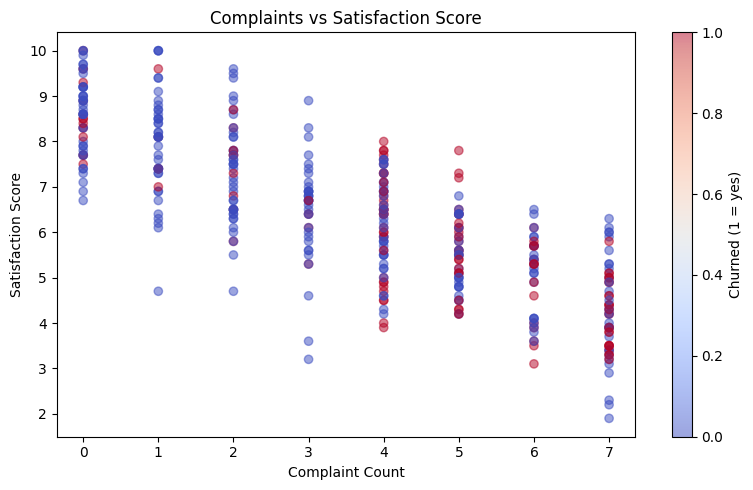

Correlation between ComplaintCount and SatisfactionScore: -0.810


In [ ]:
correlation = df['ComplaintCount'].corr(df['SatisfactionScore'])

plt.scatter(df['ComplaintCount'], df['SatisfactionScore'], alpha=0.5, c=df['Churned'], cmap='coolwarm')
plt.title('Complaints vs Satisfaction Score')
plt.xlabel('Complaint Count')
plt.ylabel('Satisfaction Score')
plt.colorbar(label='Churned (1 = yes)')
plt.tight_layout()
plt.show()

print(f"Correlation between ComplaintCount and SatisfactionScore: {correlation:.3f}")

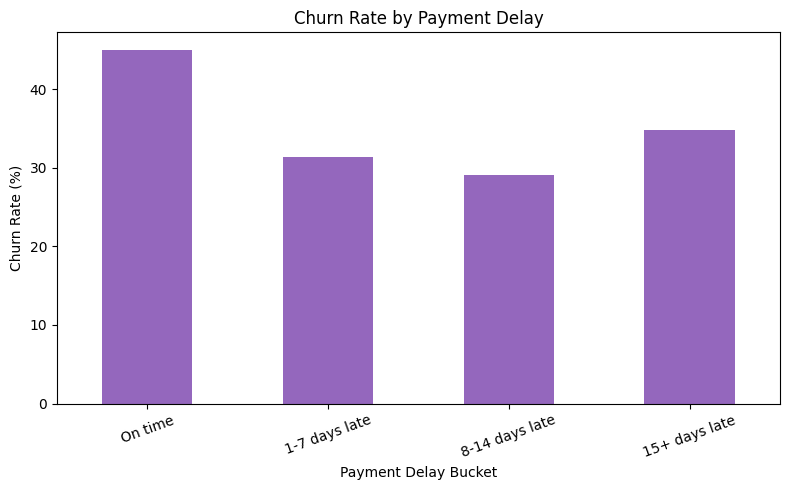

PaymentDelayBucket
On time           45.000000
1-7 days late     31.325301
8-14 days late    29.090909
15+ days late     34.759358
Name: Churned, dtype: float64


In [ ]:
df['PaymentDelayBucket'] = pd.cut(df['PaymentDelayDays'], bins=[-1, 0, 7, 14, 100],
                                   labels=['On time', '1-7 days late', '8-14 days late', '15+ days late'])
churn_by_delay = df.groupby('PaymentDelayBucket', observed=True)['Churned'].mean() * 100

churn_by_delay.plot(kind='bar', color='#9467bd')
plt.title('Churn Rate by Payment Delay')
plt.xlabel('Payment Delay Bucket')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(churn_by_delay)

In [ ]:
model_df = df.drop(columns=['CustomerID'])
if 'PaymentDelayBucket' in model_df.columns:
    model_df = model_df.drop(columns=['PaymentDelayBucket'])  # only used for the chart above

model_df = pd.get_dummies(model_df, columns=['Region', 'AgeGroup', 'Gender', 'SubscriptionPlan', 'Channel'],
                           drop_first=True)

X = model_df.drop(columns=['Churned'])
y = model_df['Churned']

print("Features used:", list(X.columns))
print("X shape:", X.shape)

Features used: ['TenureMonths', 'MonthlyChargeFRW', 'DataUsedGB', 'CallMinutes', 'SMSCount', 'ComplaintCount', 'SupportCalls', 'NetworkQualityScore', 'PaymentDelayDays', 'SatisfactionScore', 'TotalRevenue6M', 'Region_Kigali', 'Region_Northern Province', 'Region_Southern Province', 'Region_Western Province', 'AgeGroup_25-34', 'AgeGroup_35-44', 'AgeGroup_45-54', 'AgeGroup_55+', 'Gender_Male', 'SubscriptionPlan_Business', 'SubscriptionPlan_Premium', 'SubscriptionPlan_Standard', 'Channel_Mobile App', 'Channel_Ussd', 'Channel_Walk-In', 'Channel_Web']
X shape: (400, 27)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (320, 27)  Test size: (80, 27)


In [ ]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy:  0.550
Precision: 0.353
Recall:    0.462
F1 Score:  0.400
Confusion Matrix:
[[32 22]
 [14 12]]


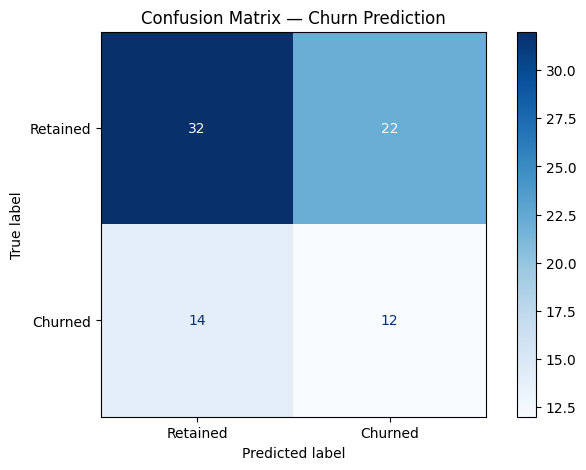

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned']).plot(cmap='Blues')
plt.title('Confusion Matrix — Churn Prediction')
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()
print(f"False Negatives (missed churners): {fn}")
print("These are customers the model predicted would stay, but who actually churned.")

False Negatives (missed churners): 14
These are customers the model predicted would stay, but who actually churned.
